In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import zipfile
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf

from sklearn.utils import class_weight


from PIL import Image
from IPython.display import display

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.models import load_model

import warnings
warnings.filterwarnings('ignore')


In [ ]:
# extracting image data from a zip file

zip_path = '/content/drive/MyDrive/MLPR Images-20250416T151754Z-001.zip' # zip file path
extract_dir = '/content/MLPR_Images_Extracted' # path to extract the zip file
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extraction completed!")


Extraction completed!


In [ ]:
# Resize the image and save to a new directory
image_dir = '/content/MLPR_Images_Extracted/MLPR Images'
resize_dir = '/content/MLPR_Images_Resized'
target_size = (224, 224)

os.makedirs(resize_dir, exist_ok=True)

for folder in sorted(os.listdir(image_dir)):
    source = os.path.join(image_dir, folder)
    destination = os.path.join(resize_dir, folder)
    if os.path.isdir(source):
        os.makedirs(destination, exist_ok=True)
        for img_name in os.listdir(source):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                try:
                    img = Image.open(os.path.join(source, img_name)).convert('RGB')
                    img.resize(target_size).save(os.path.join(destination, img_name))
                except Exception as e:
                    print(f" Error processing {img_name}: {e}")


In [ ]:
# checking the distribution of each classes
classes = (os.listdir(resize_dir))
print(classes)
print('Total Classes : {}'.format(len(classes)))

# Counting the total number of files in each class directory
file_counts = {cls: len([f for f in os.listdir(os.path.join(image_dir, cls))
                if os.path.isfile(os.path.join(image_dir, cls, f))])
                for cls in classes}
# Print file counts
for cls, count in file_counts.items():
    print(f"{cls}: {count} files")


['Product_2', 'Product_3', 'Product_1', 'Product_5', 'Product_4', 'Background']
Total Classes : 6
Product_2: 14 files
Product_3: 400 files
Product_1: 500 files
Product_5: 600 files
Product_4: 385 files
Background: 39 files
{np.str_('Background'): 0, np.str_('Product_1'): 1, np.str_('Product_2'): 2, np.str_('Product_3'): 3, np.str_('Product_4'): 4, np.str_('Product_5'): 5}


The dataset shows  **class imbalance**, especially for `Product_2` and `Background`, which may affect model performance. Techniques like data augmentation or class weighting might be necessary.


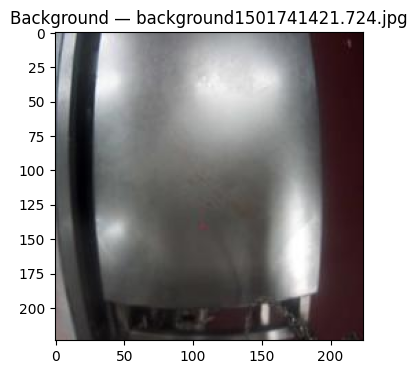

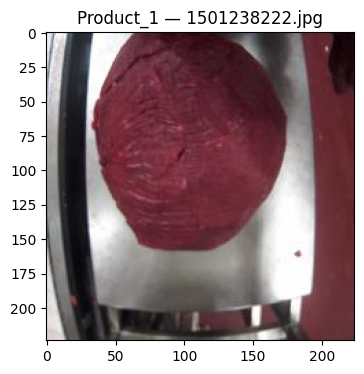

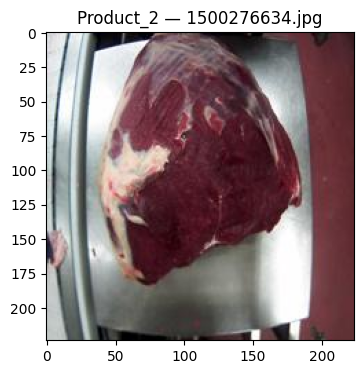

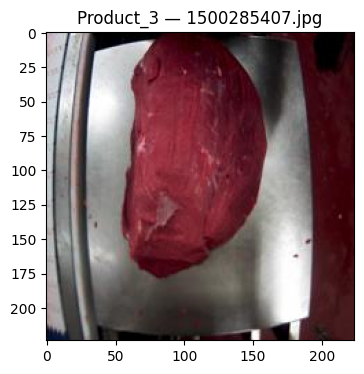

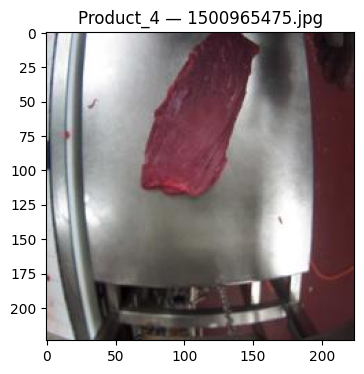

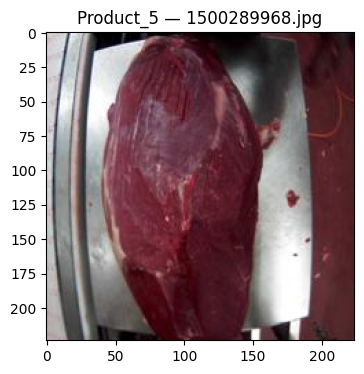

In [ ]:
# Visualizing one random image from each directory
classes = sorted([d for d in os.listdir(resize_dir) if os.path.isdir(os.path.join(resize_dir, d))])

for cls in classes:
    cls_path = os.path.join(resize_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if images:
        img_name = random.choice(images)
        img_path = os.path.join(cls_path, img_name)
        img = mpimg.imread(img_path)

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f'{cls} — {img_name}')
        plt.show()


#Train validation split

In [ ]:
resize_dir = '/content/MLPR_Images_Resized' # Directory with resized images

# Split configuration
batch_size = 32
img_size = (224, 224)  # we have already resized to this
seed = 123  # for reproducibility

# Loading training dataset (80%)
train_data = image_dataset_from_directory(
    resize_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

# Load validation dataset (20%)
val_data = image_dataset_from_directory(
    resize_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

# Class names
class_names = train_data.class_names
print(f"\nClass names: {class_names}")


Found 1938 files belonging to 6 classes.
Using 1551 files for training.
Found 1938 files belonging to 6 classes.
Using 387 files for validation.

Class names: ['Background', 'Product_1', 'Product_2', 'Product_3', 'Product_4', 'Product_5']


In [ ]:
#Performance Optimizations
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)


 # Handling Class Imbalance

To handle class imbalance in the dataset, class weights are calculated using `sklearn.utils.class_weight`.
Since `Product_2` and `Background` have fewer images compared to the other classes that may become biased towards predicting majority classes




In [ ]:
resize_dir = '/content/MLPR_Images_Resized'
class_names = sorted(os.listdir(resize_dir))
# Count images per class
image_count_per_class = [
    len([f for f in os.listdir(os.path.join(resize_dir, cls))
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    for cls in class_names
]

# Creating a target labels for sklearn's class_weight
y_labels = []
for i, count in enumerate(image_count_per_class):
    y_labels.extend([i] * count)

# Computing class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)

# Convert to dictionary
class_weights_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weights_dict)


Class weights: {0: np.float64(8.282051282051283), 1: np.float64(0.646), 2: np.float64(23.071428571428573), 3: np.float64(0.8075), 4: np.float64(0.8389610389610389), 5: np.float64(0.5383333333333333)}


In [ ]:
# Define the CNN Model
from tensorflow.keras import layers, models

def create_cnn_model(input_shape=(224, 224, 3), num_classes=6):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
# Print CNN model summary
cnn_model = create_cnn_model()
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model with class weights
history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weights_dict
)


Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 226ms/step - accuracy: 0.3433 - loss: 108.1836 - val_accuracy: 0.4160 - val_loss: 1.2513
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.5643 - loss: 1.2511 - val_accuracy: 0.5995 - val_loss: 1.1690
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5592 - loss: 1.0569 - val_accuracy: 0.7209 - val_loss: 0.6901
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.6649 - loss: 0.8245 - val_accuracy: 0.4755 - val_loss: 1.4173
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5727 - loss: 0.9067 - val_accuracy: 0.7907 - val_loss: 0.5383
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.6718 - loss: 0.8271 - val_accuracy: 0.7545 - val_loss: 0.6449
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7145 - loss: 0.7509 - val_accuracy: 0.8062 - val_loss: 0.5034
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8003 - loss: 0.4511 - val_accuracy: 0.7829

In [ ]:
# Evaluate on validation set
val_loss, val_acc = cnn_model.evaluate(val_data)
print(f"Validation accuracy: {val_acc:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8956 - loss: 0.3869
Validation accuracy: 0.8708


In [ ]:
# Save the Model
cnn_model.save('/content/cnn_model.h5')  # HDF5 format

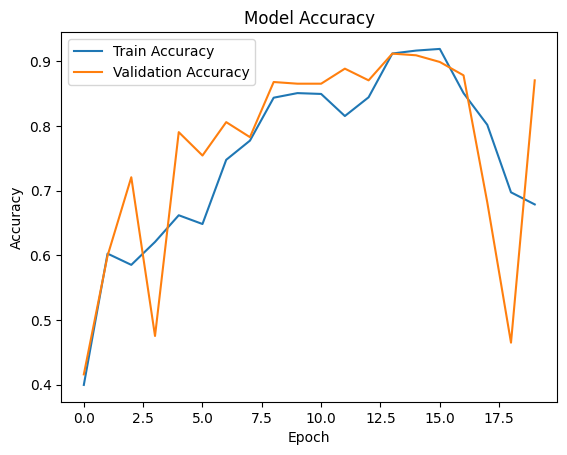

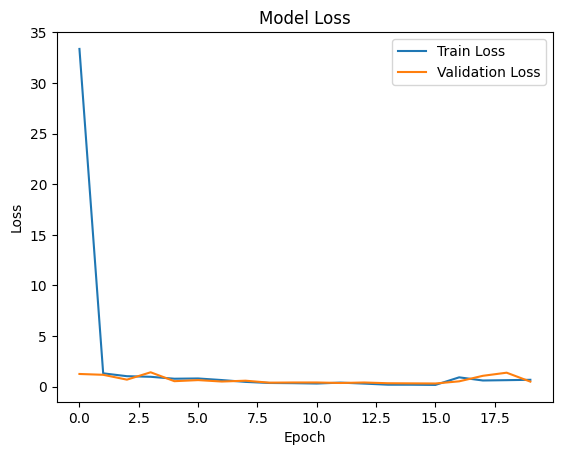

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


## Transfer Learning Model Using MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

def create_transfer_model(input_shape=(224, 224, 3), num_classes=6):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze the base model

    # Build the full model
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
# Print the summary
transfer_model = create_transfer_model()
transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#Train the Transfer Learning Model
history_tl = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weights_dict
)


Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 264ms/step - accuracy: 0.3659 - loss: 1.8407 - val_accuracy: 0.8450 - val_loss: 0.6810
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6524 - loss: 0.8526 - val_accuracy: 0.8088 - val_loss: 0.6769
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7146 - loss: 0.6895 - val_accuracy: 0.8734 - val_loss: 0.4646
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7465 - loss: 0.6326 - val_accuracy: 0.8579 - val_loss: 0.4738
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7746 - loss: 0.5120 - val_accuracy: 0.7804 - val_loss: 0.5566
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8050 - loss: 0.4459 - val_accuracy: 0.8372 - val_loss: 0.4337
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8465 - loss: 0.3905 - val_accuracy: 0.8941 - val_loss: 0.3485
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8553 - loss: 0.3519 - val_accuracy: 0.8630 -

In [ ]:
# Fine-tuning the Base Model
transfer_model.trainable = True # Unfreeze the base model for fine-tuning

# Recompile with a lower learning rate
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # Smaller LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
fine_tune_epochs = 5
history_fine = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=fine_tune_epochs,
    class_weight=class_weights_dict
)


Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 185ms/step - accuracy: 0.8922 - loss: 0.3013 - val_accuracy: 0.9096 - val_loss: 0.2802
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8819 - loss: 0.2868 - val_accuracy: 0.9044 - val_loss: 0.2779
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9135 - loss: 0.2868 - val_accuracy: 0.9044 - val_loss: 0.2764
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9030 - loss: 0.2537 - val_accuracy: 0.9044 - val_loss: 0.2746
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9040 - loss: 0.2349 - val_accuracy: 0.9096 - val_loss: 0.2730


In [ ]:
# Save the model
transfer_model.save('/content/transfer_model.h5')

In [ ]:
# Evaluate on validation set after fine-tuning
val_loss, val_acc = transfer_model.evaluate(val_data)
print(f"Validation Accuracy after fine-tuning: {val_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9105 - loss: 0.2722
Validation Accuracy after fine-tuning: 0.9096


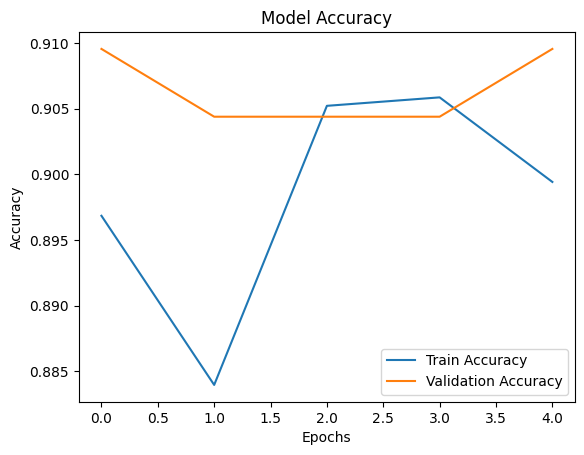

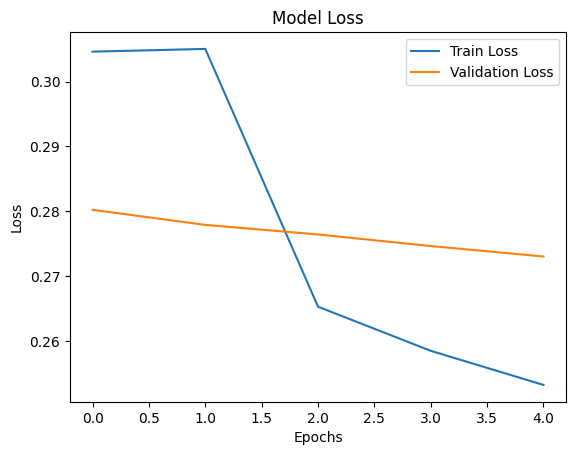

In [ ]:
# Plot the training and validation accuracy
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot the training and validation loss
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
#  Extract Final Accuracy
# CNN final accuracies
cnn_train_acc = history.history['accuracy'][-1]
cnn_val_acc = history.history['val_accuracy'][-1]

# Transfer Learning final accuracies
tl_train_acc = history_tl.history['accuracy'][-1]
tl_val_acc = history_tl.history['val_accuracy'][-1]
print("Model Accuracy Comparison:\n")
print(f"CNN Model       -> Training Accuracy: {cnn_train_acc:.4f}, Validation Accuracy: {cnn_val_acc:.4f}")
print(f"Transfer Model  -> Training Accuracy: {tl_train_acc:.4f}, Validation Accuracy: {tl_val_acc:.4f}")



Model Accuracy Comparison:

CNN Model       -> Training Accuracy: 0.6789, Validation Accuracy: 0.8708
Transfer Model  -> Training Accuracy: 0.8485, Validation Accuracy: 0.9070


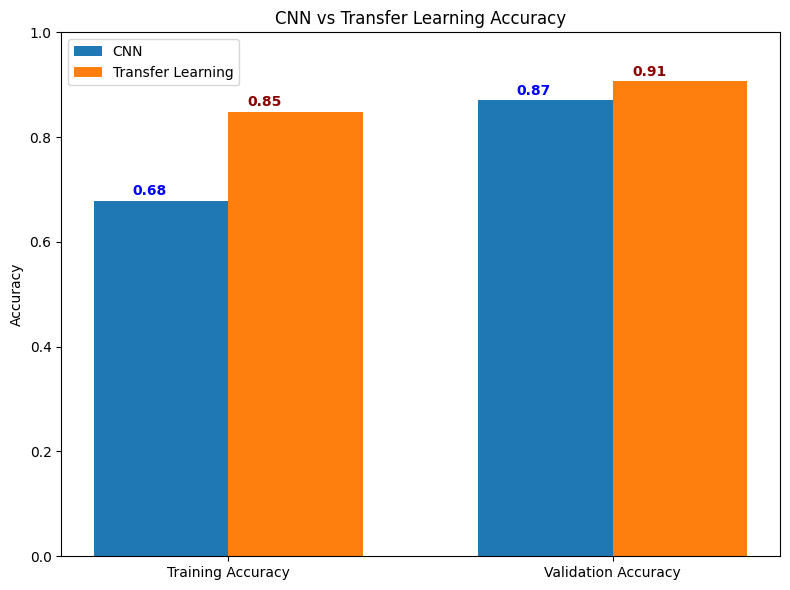

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Training Accuracy', 'Validation Accuracy']
cnn_scores = [cnn_train_acc, cnn_val_acc]
tl_scores = [tl_train_acc, tl_val_acc]

x = np.arange(len(labels))  # the label locations
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, cnn_scores, width, label='CNN')
rects2 = ax.bar(x + width/2, tl_scores, width, label='Transfer Learning')

# Labels and formatting
ax.set_ylabel('Accuracy')
ax.set_title('CNN vs Transfer Learning Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim([0, 1])
ax.legend()

for i in range(len(labels)):
    ax.text(i - 0.25, cnn_scores[i] + 0.01, f'{cnn_scores[i]:.2f}', color='blue', fontweight='bold')
    ax.text(i + 0.05, tl_scores[i] + 0.01, f'{tl_scores[i]:.2f}', color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8956 - loss: 0.3869
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9105 - loss: 0.2722


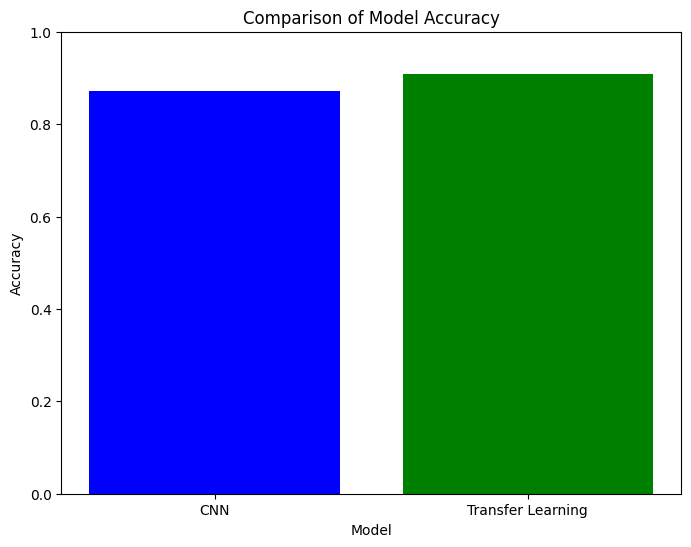

In [ ]:
# Accuracy Comaprison
import matplotlib.pyplot as plt

# Get accuracy values for both models (assuming 'val_acc' from training history)
cnn_accuracy = cnn_model.evaluate(val_data)[1]  # Assuming the second value is accuracy
tl_accuracy = transfer_model.evaluate(val_data)[1]  # Assuming the second value is accuracy

# Plotting the bar chart
models = ['CNN', 'Transfer Learning']
accuracies = [cnn_accuracy, tl_accuracy]

plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['blue', 'green'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracy')
plt.ylim(0, 1)  # Set y-axis limit from 0 to 1 (for accuracy)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


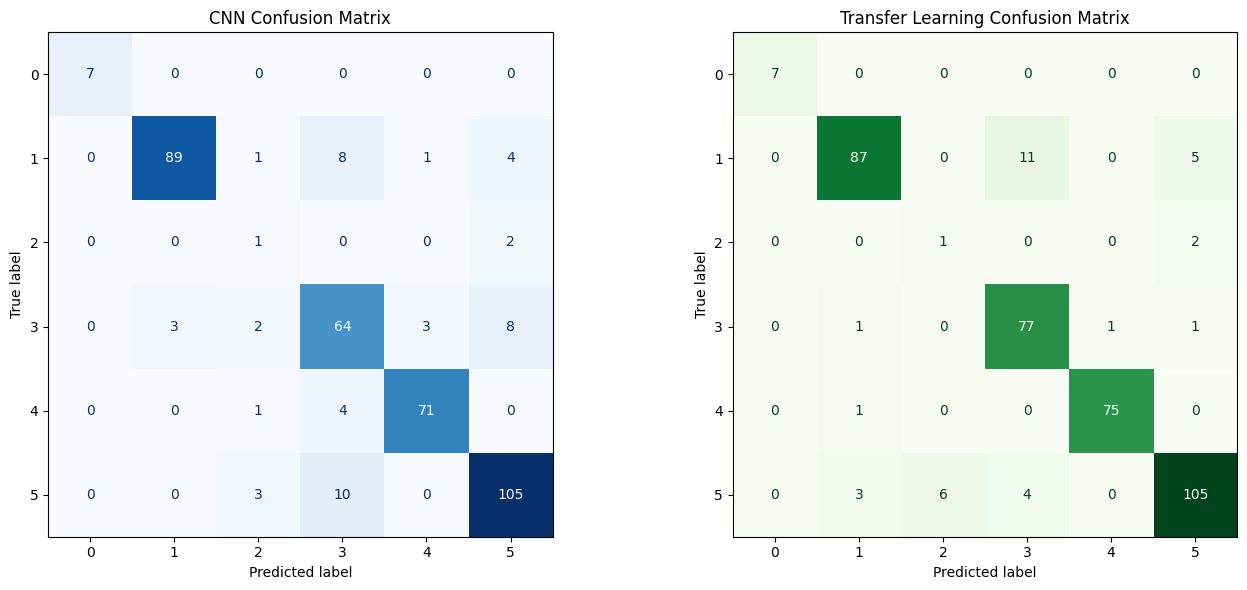

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_preds_labels(model, dataset):
    y_true = []
    y_pred = []
    for images, labels in dataset:
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

# For CNN
cnn_y_true, cnn_y_pred = get_preds_labels(cnn_model, val_data)
# For Transfer Learning
tl_y_true, tl_y_pred = get_preds_labels(transfer_model, val_data)

# Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay.from_predictions(cnn_y_true, cnn_y_pred, ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title("CNN Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(tl_y_true, tl_y_pred, ax=ax[1], cmap='Greens', colorbar=False)
ax[1].set_title("Transfer Learning Confusion Matrix")
plt.tight_layout()
plt.show()


In [ ]:
# Precision, Recall, F1-score Table
from sklearn.metrics import classification_report

class_names = sorted(os.listdir(resize_dir))

print("🔍 Classification Report — CNN Model:\n")
print(classification_report(cnn_y_true, cnn_y_pred, target_names=class_names))

print("\n🔍 Classification Report — Transfer Learning Model:\n")
print(classification_report(tl_y_true, tl_y_pred, target_names=class_names))


🔍 Classification Report — CNN Model:

              precision    recall  f1-score   support

  Background       1.00      1.00      1.00         7
   Product_1       0.97      0.86      0.91       103
   Product_2       0.12      0.33      0.18         3
   Product_3       0.74      0.80      0.77        80
   Product_4       0.95      0.93      0.94        76
   Product_5       0.88      0.89      0.89       118

    accuracy                           0.87       387
   macro avg       0.78      0.80      0.78       387
weighted avg       0.89      0.87      0.88       387


🔍 Classification Report — Transfer Learning Model:

              precision    recall  f1-score   support

  Background       1.00      1.00      1.00         7
   Product_1       0.95      0.84      0.89       103
   Product_2       0.14      0.33      0.20         3
   Product_3       0.84      0.96      0.90        80
   Product_4       0.99      0.99      0.99        76
   Product_5       0.93      0.89      0.

In [ ]:
cnn_model = load_model('/content/cnn_model.h5')
transfer_model = load_model('/content/transfer_model.h5')

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the image you want to predict
img_path = '/content/MLPR_Images_Resized/Background/background1501738861.155.jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension



In [ ]:
# Make a prediction on CNN
cnn_predictions = cnn_model.predict(img_array)
predicted_class = np.argmax(cnn_predictions)  # Get the class with the highest probability
print(f"Predicted class: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted class: 0


In [ ]:
# Make a prediction on Transfer Learning
transfer_predictions = transfer_model.predict(img_array)
predicted_class = np.argmax(transfer_predictions)  # Get the class with the highest probability
print(f"Predicted class: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted class: 0
